In [3]:
import pandas as pd

car_stocks = pd.read_csv('../data/car_stocks.csv')

dtype('O')

In [7]:
#Aveage closing price of RIVN, GM, LCID  Groupby instead of filtering by Symbols
print('GM', car_stocks[car_stocks['Symbol'] == 'GM']['Close'].mean())
#Uses Lazy loading
car_stocks.groupby('Symbol')['Close'].mean()

GM 62.16461546153845


Symbol
GM       62.164615
LCID     49.829231
RIVN    127.523077
Name: Close, dtype: float64

In [8]:
titanic = pd.read_csv('../data/titanic.csv')
titanic['age'] = titanic['age'].replace(['?'], [None]).astype('float')

In [11]:
df = titanic[['pclass', 'survived', 'sex', 'age']]
gbo = df.groupby(by='sex') #group by object
gbo.ngroups

2

In [12]:
gbo.groups #prints indices

{'female': [0, 2, 4, 6, 8, 11, 12, 13, 17, 18, 21, 23, 24, 27, 28, 32, 33, 35, 36, 41, 42, 43, 44, 48, 50, 55, 57, 59, 61, 63, 65, 66, 67, 69, 72, 73, 76, 78, 79, 82, 83, 85, 88, 90, 92, 95, 97, 98, 99, 102, 103, 104, 105, 107, 108, 111, 112, 113, 116, 117, 121, 122, 124, 127, 129, 130, 131, 134, 137, 139, 141, 144, 146, 149, 153, 155, 159, 160, 161, 163, 167, 168, 169, 176, 178, 180, 181, 182, 186, 187, 188, 190, 192, 193, 195, 198, 199, 204, 207, 208, ...], 'male': [1, 3, 5, 7, 9, 10, 14, 15, 16, 19, 20, 22, 25, 26, 29, 30, 31, 34, 37, 38, 39, 40, 45, 46, 47, 49, 51, 52, 53, 54, 56, 58, 60, 62, 64, 68, 70, 71, 74, 75, 77, 80, 81, 84, 86, 87, 89, 91, 93, 94, 96, 100, 101, 106, 109, 110, 114, 115, 118, 119, 120, 123, 125, 126, 128, 132, 133, 135, 136, 138, 140, 142, 143, 145, 147, 148, 150, 151, 152, 154, 156, 157, 158, 162, 164, 165, 166, 170, 171, 172, 173, 174, 175, 177, 179, 183, 184, 185, 189, 191, ...]}

In [13]:
gbo.first() #gives first member of each group

,pclass,survived,age
sex,,,
female,1,1,29.0000
male,1,1,0.9167


In [14]:
gbo.get_group('female')

,pclass,survived,sex,age
0,1,1,female,29.0
2,1,0,female,2.0
4,1,0,female,25.0
6,1,1,female,63.0
8,1,1,female,53.0
...,...,...,...,...
1286,3,1,female,38.0
1290,3,1,female,47.0
1300,3,1,female,15.0
1304,3,0,female,14.5


In [16]:
for name, group in gbo:
    print(name)
    print('-----------')
    print(type(group))
    print(group)

female
-----------
<class 'pandas.core.frame.DataFrame'>
      pclass  survived     sex   age
0          1         1  female  29.0
2          1         0  female   2.0
4          1         0  female  25.0
6          1         1  female  63.0
8          1         1  female  53.0
...      ...       ...     ...   ...
1286       3         1  female  38.0
1290       3         1  female  47.0
1300       3         1  female  15.0
1304       3         0  female  14.5
1305       3         0  female   NaN

[466 rows x 4 columns]
male
-----------
<class 'pandas.core.frame.DataFrame'>
      pclass  survived   sex      age
1          1         1  male   0.9167
3          1         0  male  30.0000
5          1         1  male  48.0000
7          1         0  male  39.0000
9          1         0  male  71.0000
...      ...       ...   ...      ...
1302       3         0  male      NaN
1303       3         0  male      NaN
1306       3         0  male  26.5000
1307       3         0  male  27.0000
13

In [17]:
#SPLIT APPLY(apply functions to groups)  COMBINE
gbo['age'].mean() #Groupby Object Series

sex
female    28.687071
male      30.585233
Name: age, dtype: float64

In [18]:
gbo['age'].max()

sex
female    76.0
male      80.0
Name: age, dtype: float64

<Axes: title={'center': 'Average Age By Sex'}, xlabel='sex'>

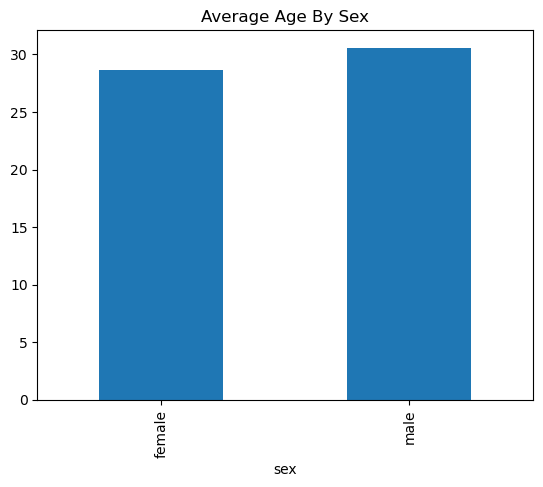

In [19]:
gbo['age'].mean().plot(kind='bar', title='Average Age By Sex')

In [21]:
titanic.groupby('pclass')['age'].mean()

pclass
1    39.159918
2    29.506705
3    24.816367
Name: age, dtype: float64

In [23]:
titanic.mean(numeric_only=True)

pclass       2.294882
survived     0.381971
age         29.881135
sibsp        0.498854
parch        0.385027
dtype: float64

In [25]:
titanic.groupby('sex').mean(numeric_only=True)

,pclass,survived,age,sibsp,parch
sex,,,,,
female,2.154506,0.727468,28.687071,0.652361,0.633047
male,2.372479,0.190985,30.585233,0.413998,0.247924


In [26]:
car_stocks.groupby('Symbol')['High'].max()

Symbol
GM       65.180000
LCID     57.750000
RIVN    179.470001
Name: High, dtype: float64

In [30]:
#Aggregate  aggregate/agg    run multiple functions on groupby object
titanic.groupby('sex')['age'].agg(['min', 'max', 'mean'])

,min,max,mean
sex,,,
female,0.1667,76.0,28.687071
male,0.3333,80.0,30.585233


In [35]:
titanic.groupby('sex')[['pclass', 'survived', 'age', 'sibsp', 'parch']].agg(['min', 'max', 'mean'])

pclass               survived      ... sibsp           parch              
          min max      mean      min max  ...   max      mean   min max      mean
sex                                       ...                                    
female      1   3  2.154506        0   1  ...     8  0.652361     0   9  0.633047
male        1   3  2.372479        0   1  ...     8  0.413998     0   9  0.247924

[2 rows x 15 columns]

In [36]:
titanic.groupby('sex').agg({"age": ['min', 'max'], 'pclass': ['mean']})

age          pclass
           min   max      mean
sex                           
female  0.1667  76.0  2.154506
male    0.3333  80.0  2.372479

In [41]:
def range(x):
    print( x.max(), x.min()) # x = age series for group 1, 2, 3
    return x.max() - x.min()
titanic.groupby('pclass')['age'].agg(['min', 'max', range]) #.agg(range)

80.0 0.9167
70.0 0.6667
74.0 0.1667


,min,max,range
pclass,,,
1,0.9167,80.0,79.0833
2,0.6667,70.0,69.3333
3,0.1667,74.0,73.8333


In [43]:
titanic['age'].size - titanic['age'].count() #size = rows count = non nullvalue

np.int64(263)

In [45]:
def count_nulls(s):
    return s.size - s.count()
titanic.groupby('pclass')['age'].agg(count_nulls) 

pclass
1     39
2     16
3    208
Name: age, dtype: int64

In [46]:
#Named aggragation
car_stocks.groupby('Symbol').agg({"Open": ['min', 'max'], "Close": ['min', 'max']})

Open                   Close            
               min         max         min         max
Symbol                                                
GM       57.849998   64.330002   59.270000   64.610001
LCID     42.299999   56.200001   40.750000   55.520000
RIVN    106.750000  163.800003  100.730003  172.009995

In [48]:
car_stocks.groupby('Symbol').agg(
    min_open=('Open', 'min'),
    max_open=('Open', 'max'),
    min_close=('Close', 'min'),
    max_close=('Close', 'max')
)

,min_open,max_open,min_close,max_close
Symbol,,,,
GM,57.849998,64.330002,59.270000,64.610001
LCID,42.299999,56.200001,40.750000,55.520000
RIVN,106.750000,163.800003,100.730003,172.009995
